## 1. Imports and Model Loading

In [1]:
import sys
import os
from tqdm import tqdm
import cv2
from matplotlib import pyplot as plt
import numpy as np

parent_dir = os.path.dirname(os.getcwd())
sys.path.insert(0, parent_dir)

os.environ["MOMENTUM_ENABLED"] = "1"

from utils import (
    setup_sam_3d_body, setup_visualizer, 
    visualize_2d_results, visualize_3d_mesh, save_mesh_results, 
    display_results_grid, process_image_with_mask
)

# Set up SAM 3D Body estimator using local checkpoint
checkpoint_dir = os.path.join(parent_dir, "checkpoints", "sam-3d-body-dinov3")
estimator = setup_sam_3d_body(checkpoint_dir=checkpoint_dir)
# Set up visualizer
visualizer = setup_visualizer()

/home/rikhat/human_global_motion/sam-3d-body/sam_3d_body/models/heads/mhr_head.py:29: UserWarning: Momentum is not enabled
  warnings.warn("Momentum is not enabled")
/home/rikhat/human_global_motion/sam-3d-body/sam_3d_body/models/heads/mhr_head.py:33: UserWarning: Momentum is not enabled
  warnings.warn("Momentum is not enabled")


Loading SAM 3D Body model from local checkpoint: /home/rikhat/human_global_motion/sam-3d-body/checkpoints/sam-3d-body-dinov3...
CKPT PATH: /home/rikhat/human_global_motion/sam-3d-body/checkpoints/sam-3d-body-dinov3/model.ckpt
MHR PATH: /home/rikhat/human_global_motion/sam-3d-body/checkpoints/sam-3d-body-dinov3/assets/mhr_model.pt
Loading SAM 3D Body model...


Using cache found in /home/rikhat/.cache/torch/hub/facebookresearch_dinov3_main
Ignored kwargs: {'drop_path': 0.1}
The model and loaded state dict do not match exactly

missing keys in source state_dict: backbone.encoder.mask_token, head_pose.hand_pose_comps_ori, head_pose.mhr.face_expressions_model.shape_vectors, head_pose.mhr.pose_correctives_model.pose_dirs_predictor.0.sparse_indices, head_pose.mhr.pose_correctives_model.pose_dirs_predictor.0.sparse_weight, head_pose.mhr.pose_correctives_model.pose_dirs_predictor.2.weight, head_pose.mhr.character_torch.skeleton.joint_translation_offsets, head_pose.mhr.character_torch.skeleton.joint_prerotations, head_pose.mhr.character_torch.skeleton.pmi, head_pose.mhr.character_torch.skeleton.joint_parents, head_pose.mhr.character_torch.mesh.rest_vertices, head_pose.mhr.character_torch.mesh.faces, head_pose.mhr.character_torch.mesh.texcoords, head_pose.mhr.character_torch.mesh.texcoord_faces, head_pose.mhr.character_torch.parameter_transform.parame

Loading human detector from vitdet...
########### Using human detector: ViTDet...


/home/rikhat/miniconda3/envs/mhr/lib/python3.12/site-packages/detectron2/config/lazy.py:167: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return old_import(name, globals, locals, fromlist=fromlist, level=level)
/home/rikhat/miniconda3/envs/mhr/lib/python3.12/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


Loading FOV estimator from moge2...
########### Using fov estimator: MoGe2...
Mask-condition inference is not supported...
Setup complete!
  Human detector: ✓
  Human segmentor: ✗ (mask inference disabled)
  FOV estimator: ✓


## 2. Process Image and Get Outputs

In [2]:
folder_path = "../../../climbing/climb_forces/data/eth/1/frames/03_laddering1/left"
images_list = os.listdir(folder_path)
images_list.sort()

# writer = cv2.VideoWriter('output/climbing.mp4', cv2.VideoWriter_fourcc(*'mp4v'), 30, (1920, 1080))

for img_name in images_list:
    img_path = os.path.join(folder_path, img_name)
    print(f"Processing image: {img_path}")
    output = estimator.process_one_image(img_path)

    img_cv2 = cv2.imread(os.path.join(folder_path, img_name))

    mesh_results = visualize_3d_mesh(img_cv2, output, estimator.faces)

    new_img = np.zeros((1080 *2, 1920*2, 3), dtype=np.uint8)
    new_img[0:1080, 0:1920, :] = mesh_results[0][:, :1920]
    new_img[0:1080, 1920:1920*2, :] = mesh_results[0][:, 1920:1920*2]
    new_img[1080:1080*2, 0:1920, :] = mesh_results[0][:, 1920*2:1920*3]
    new_img[1080:1080*2, 1920:1920*2, :] = mesh_results[0][:, 1920*3:1920*4]
    new_img = cv2.resize(new_img, (1920, 1080))

    break

    # writer.write(new_img)

# writer.release()

Processing image: ../../../climbing/climb_forces/data/eth/1/frames/03_laddering1/left/000000.jpg


/home/rikhat/miniconda3/envs/mhr/lib/python3.12/site-packages/torch/functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4322.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [3]:
output[0].keys()

dict_keys(['bbox', 'focal_length', 'pred_keypoints_3d', 'pred_keypoints_2d', 'pred_vertices', 'pred_cam_t', 'pred_pose_raw', 'global_rot', 'body_pose_params', 'hand_pose_params', 'scale_params', 'shape_params', 'expr_params', 'mask', 'pred_joint_coords', 'pred_global_rots', 'mhr_model_params', 'contact_logits', 'contact_probs', 'lhand_bbox', 'rhand_bbox'])

In [4]:
print(output[0]['contact_logits'])

[-0.05956062 -0.18911846 -0.11127721 -0.07946204]


In [5]:
print(output[0]['contact_probs'])

[0.48511425 0.45286077 0.4722094  0.48014492]


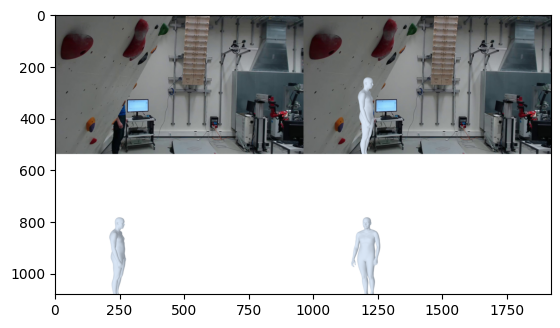

In [3]:
plt.imshow(cv2.cvtColor(new_img, cv2.COLOR_BGR2RGB))

## 3. 2D Visualization - Keypoints and Bounding Boxes

(1080, 7680, 3)


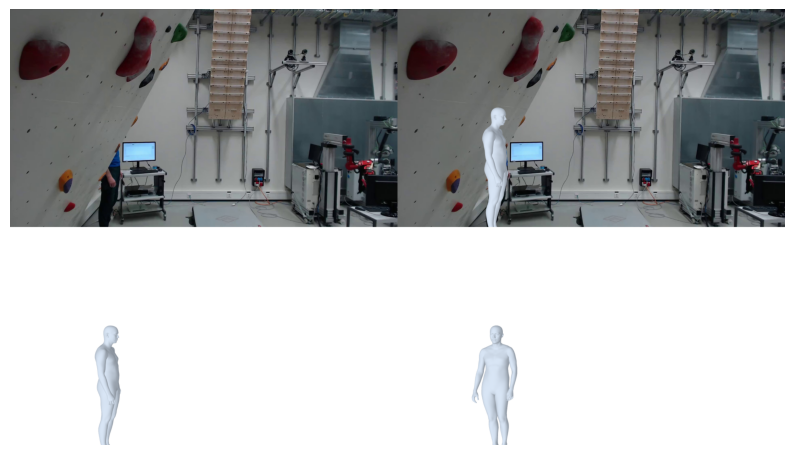

In [18]:
img_cv2 = cv2.imread(os.path.join(folder_path, images_list[0]))

mesh_results = visualize_3d_mesh(img_cv2, all_outputs[0], estimator.faces)
print(mesh_results[0].shape)

img_1 = mesh_results[0][:, :1920]
img_2 = mesh_results[0][:, 1920:1920*2]
img_3 = mesh_results[0][:, 1920*2:1920*3]
img_4 = mesh_results[0][:, 1920*3:1920*4]

new_img = np.zeros((1080 *2, 1920*2, 3), dtype=np.uint8)
new_img[0:1080, 0:1920, :] = img_1
new_img[0:1080, 1920:1920*2, :] = img_2
new_img[1080:1080*2, 0:1920, :] = img_3
new_img[1080:1080*2, 1920:1920*2, :] = img_4
new_img = cv2.resize(new_img, (1920, 1080))

plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(new_img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

## 4. 3D Mesh Visualization - Overlay and Side View

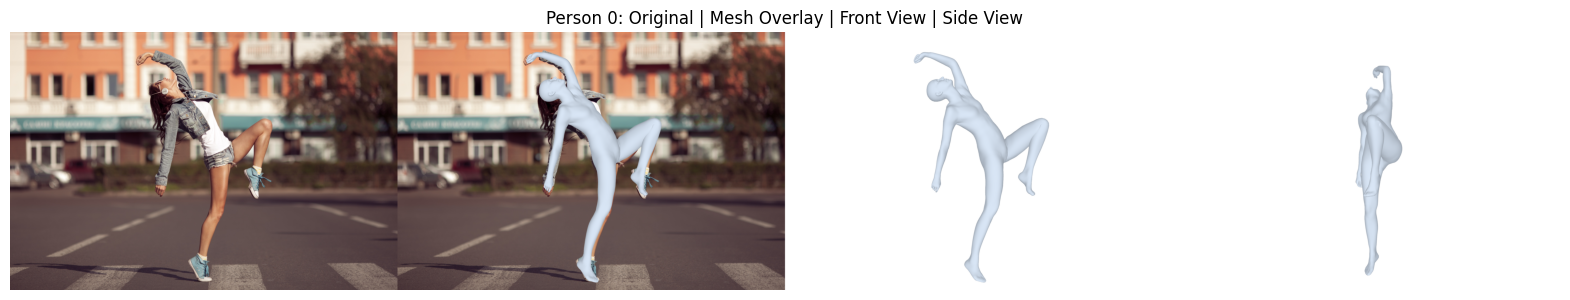

In [ ]:
if outputs:
    mesh_results = visualize_3d_mesh(img_cv2, outputs, estimator.faces)
    
    # Display results
    for i, combined_img in enumerate(mesh_results):
        combined_rgb = cv2.cvtColor(combined_img, cv2.COLOR_BGR2RGB)
        
        plt.figure(figsize=(20, 5))
        plt.imshow(combined_rgb)
        plt.title(f'Person {i}: Original | Mesh Overlay | Front View | Side View')
        plt.axis('off')
        plt.show()
else:
    print("No people detected for 3D mesh visualization")